# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

---
Para realizar esta tarea se comenzará con la limpieza de datos como es habitual y se prepararán datos derivados en caso de ser necesario, esto incluye calcular cuál fue el ingreso de cada usuario durante cada mes de acuerdo a las condiciones detalladas en la Descripción.

Después al analizar el comportamiento de los clientes se mostrarán las cantidades de usuarios de cada plan, se explorarán las distintas ciudades y se graficarán los datos de llamadas y mensajes para cada tarifa.

Determinar qué tarifa genera más ingresos tiene dos interpretaciones: la primera es el volumen total de ingresos y la segunda es el ingreso promedio de los usuarios de cada tarifa. 
Particularmente en esta segunda interpretación se puede realizar una prueba estadística para saber si la diferencia es significativa o no.

## Inicialización

In [72]:
# Cargar todas las librerías

import pandas as pd
import numpy as np
from math import factorial, ceil
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar datos

In [73]:
# Carga los archivos de datos en diferentes DataFrames

df_plans = pd.read_csv("/datasets/megaline_plans.csv")
df_users = pd.read_csv("/datasets/megaline_users.csv")
df_calls = pd.read_csv("/datasets/megaline_calls.csv")
df_messages = pd.read_csv("/datasets/megaline_messages.csv")
df_internet= pd.read_csv("/datasets/megaline_internet.csv")

## Preparar los datos

### Tarifas

In [74]:
# Imprimir la información general/resumida sobre el DataFrame de las tarifas

df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [75]:
# Imprimir el contenido de la tabla de tarifas

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


**Conclusión**

Tras ejecutar info los tipos de dato están correctos y no hay faltantes. Sin embargo el diccionario de datos menciona un campo: **usd_monthly_fee** que no aparece en la tabla. No hay problema, se ha indicado en la descripción que las tarifas son 20 USD para el plan Surf y 70 USD para el plan Ultimate. 

#### Corregir datos

In [76]:
# Nada que hacer

#### Enriquecer los datos

In [77]:
# Se agregan las tarifas

df_plans["usd_monthly_fee"]=[20,70]

# Como la tarifa se calcula por GB se agrega gb_per_month_included

df_plans["gb_per_month_included"] = [15,30]
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_monthly_fee,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,20,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30


### Usuarios/as

In [78]:
# Imprimir la información general/resumida sobre el DataFrame de usuarios

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [79]:
# Imprimir una muestra de datos para usuarios

df_users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
417,1417,Jorge,Madden,51,"Minneapolis-St. Paul-Bloomington, MN-WI MSA",2018-06-22,ultimate,NaN
291,1291,Angeles,Mejia,65,"Indianapolis-Carmel-Anderson, IN MSA",2018-01-29,surf,NaN
349,1349,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaN
39,1039,Flo,Hicks,56,"Columbus, OH MSA",2018-05-30,ultimate,NaN
134,1134,Shannon,Nichols,71,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-09-03,surf,NaN


Una de las pruebas de hipótesis pide agrupar por el área NY-NJ. Se explorará aquí cómo obtener esa información.

In [80]:
# Mostrar los diferentes valores para 'city' de los usuarios

df_users["city"].value_counts()

New York-Newark-Jersey City, NY-NJ-PA MSA          80
Los Angeles-Long Beach-Anaheim, CA MSA             29
Dallas-Fort Worth-Arlington, TX MSA                21
Chicago-Naperville-Elgin, IL-IN-WI MSA             19
Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA    17
                                                   ..
Cape Coral-Fort Myers, FL MSA                       1
Jacksonville, FL MSA                                1
Greensboro-High Point, NC MSA                       1
Albany-Schenectady-Troy, NY MSA                     1
Raleigh-Cary, NC MSA                                1
Name: city, Length: 73, dtype: int64

**Conclusión** 

Para el campo *churn_date* solo hay 34 no nulos, esto indica que la mayoría de los usuarios continúan usando el servicio. Respecto a los tipos de datos, tanto **churn_date** como **reg_date** deberían mostrar un tipo de de dato de fecha.

Respecto a las ciudades hay 73 ciudades distintas y la más común es New York-Newark-Jersey (**NY-NJ**), el 16% de los usuarios viven ahí. los nombres son bastante largos y podría tomarse solo la parte entre ", " y " MSA" que parece agrupar bastante bien.

#### Corregir los datos

In [ ]:
# Corregir el tipo de dato de reg_date

df_users["reg_date"] = pd.to_datetime(df_users["reg_date"],format='%Y-%m-%d')
df_users["churn_date"] = pd.to_datetime(df_users["churn_date"],format='%Y-%m-%d')

In [82]:
# Validar corrección

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


In [83]:
 # Validar duplicados

df_users.duplicated().sum()

0

#### Enriquecer los datos

In [84]:
# Se agrega una columna que identifica si la ciudad/región es NY-NJ .

df_users["NY-NJ-PA"] = df_users["city"].apply(lambda x: False if x.find("NY-NJ-PA")==-1 else True)
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,NY-NJ-PA
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,False
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,False
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,False
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,False
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,False


### Llamadas

In [85]:
# Imprimir la información general/resumida sobre el DataFrame de las llamadas

df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [86]:
# Imprimr una muestra de datos para las llamadas

df_calls.sample(5)

,id,user_id,call_date,duration
54297,1196_179,1196,2018-07-20,22.78
81190,1292_142,1292,2018-10-25,0.00
51581,1185_619,1185,2018-10-15,0.46
74211,1263_195,1263,2018-04-08,10.19
137646,1499_115,1499,2018-11-29,9.31


**Conclusión**

No se observan valores ausentes. El tipo de dato del campo **call_date** nuevamente necesita ser convertido a datetime. Finalmente llamar una columna identificadora simplemente **id** puede generar conflictos y confusiones, especialmente si varias tablas tienen esa misma estructura. Llama la atención la presencia del caracter "_" en el id, de ser posible validaré que el formato es correcto. De momento lo dejaré así.

La duración en minutos incluye decimales, se usará la función techo para convertirlo al valor que se usa para el cálculo de la tarifa.

#### Corregir los datos

In [87]:
# Corregir el tipo de dato de reg_date y validar corrección

df_calls["call_date"] = pd.to_datetime(df_calls["call_date"])
df_calls.info()
df_calls.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
24211,1090_393,1090,2018-09-04,2.48
72132,1256_439,1256,2018-09-19,0.00
53767,1193_207,1193,2018-12-10,1.62
115138,1403_212,1403,2018-11-11,0.00
94791,1336_709,1336,2018-07-30,7.82


In [88]:
# Actualizar nombres de columnas

df_calls.rename(columns={'id':'call_id'}, inplace=True)
df_calls.columns

Index(['call_id', 'user_id', 'call_date', 'duration'], dtype='object')

In [89]:
# Validar duplicados

df_calls.duplicated().sum()

0

In [90]:
# Validar que sean datos de 2018

print(f"call_date entre {df_calls['call_date'].min()} y {df_calls['call_date'].max()}")

call_date entre 2018-01-15 00:00:00 y 2018-12-31 00:00:00


Aquí una revelación importante, solo se consideran **16 días de Enero**.

In [91]:
# Redondear hacia arriba la duración de las llamadas

#df_calls["duration"]=df_calls["duration"].apply("ceil") # Existen muchas llamadas con duration = 0.0 ¿se deben cobrar como un minuto?

df_calls["duration"] = df_calls["duration"].apply(lambda x: 1 if x == 0.0 else ceil(x))


In [92]:
df_calls.sample(5)

,call_id,user_id,call_date,duration
97881,1351_16,1351,2018-11-10,1
92343,1331_234,1331,2018-10-26,9
55937,1201_35,1201,2018-08-24,6
59989,1215_374,1215,2018-11-07,12
33863,1126_749,1126,2018-09-03,14


#### Enriquecer los datos

In [93]:
# Agregar el mes de la llamada

df_calls['month'] = df_calls['call_date'].dt.month
df_calls.sample(5)

,call_id,user_id,call_date,duration,month
125122,1441_6,1441,2018-12-07,6,12
62766,1226_165,1226,2018-10-15,19,10
49804,1181_3,1181,2018-10-21,18,10
59900,1215_285,1215,2018-10-02,13,10
34592,1130_112,1130,2018-10-18,7,10


### Mensajes

In [94]:
# Imprimir la información general/resumida sobre el DataFrame de los mensajes

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [95]:
# Imprimir una muestra de datos para los mensajes

df_messages.sample(5)

,id,user_id,message_date
7911,1060_247,1060,2018-10-26
8179,1061_185,1061,2018-11-16
13042,1086_72,1086,2018-12-31
35520,1230_65,1230,2018-12-14
34063,1214_157,1214,2018-11-16


**Conclusión**

No se observan valores ausentes. El tipo de dato del campo **message_date** nuevamente necesita ser convertido a datetime. Finalmente llamar una columna identificadora simplemente **id** puede generar conflictos y confusiones, como ya se ha mencionado.

#### Corregir los datos

In [96]:
# Corregir el tipo de dato de message_date y validar corrección

df_messages["message_date"] = pd.to_datetime(df_messages["message_date"])

In [97]:
# Validar corrección

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


In [98]:
# Actualizar nombres de columnas

df_messages.rename(columns={'id':'message_id'}, inplace=True)
df_messages.columns

Index(['message_id', 'user_id', 'message_date'], dtype='object')

In [99]:
 # Validar duplicados

df_messages.duplicated().sum()

0

In [100]:
# Validar que son datos de 2018

print(f"message_date entre {df_messages['message_date'].min()} y {df_messages['message_date'].max()}")

message_date entre 2018-01-15 00:00:00 y 2018-12-31 00:00:00


#### Enriquecer los datos

In [101]:
# Agregar el mes del mensaje

df_messages['month'] = df_messages['message_date'].dt.month
df_messages.sample(5)

,message_id,user_id,message_date,month
15690,1103_54,1103,2018-10-09,10
31032,1194_191,1194,2018-10-20,10
63259,1401_257,1401,2018-10-18,10
3804,1038_157,1038,2018-11-26,11
53227,1339_361,1339,2018-12-19,12


### Internet

In [102]:
# Imprimir la información general/resumida sobre el DataFrame de internet

df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [103]:
# Imprimir una muestra de datos para el tráfico de internet

df_internet.sample(5)

,id,user_id,session_date,mb_used
89316,1412_31,1412,2018-10-19,405.98
23865,1110_123,1110,2018-12-13,784.60
71871,1335_110,1335,2018-08-08,125.93
86227,1400_362,1400,2018-05-22,0.00
14305,1066_196,1066,2018-04-17,9.89


**Conclusión**

No se observan valores ausentes. El tipo de dato del campo **session_date** necesita ser convertido a datetime. El nombre *id* puede generar conflictos y confusiones, como ya se ha mencionado así que será reemplazado por un nombre más descriptivo.

#### Corregir los datos

In [104]:
# Corregir el tipo de dato de message_date y validar corrección

df_internet["session_date"] = pd.to_datetime(df_internet["session_date"])
df_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [105]:
 # Actualizar nombres de columnas
df_internet.rename(columns={'id':'internet_id'}, inplace=True)
df_internet.columns

Index(['internet_id', 'user_id', 'session_date', 'mb_used'], dtype='object')

In [106]:
# Validar que son datos de 2018

print(f"session_date entre {df_internet['session_date'].min()} y {df_internet['session_date'].max()}")

session_date entre 2018-01-15 00:00:00 y 2018-12-31 00:00:00


#### Enriquecer los datos

In [107]:
# Agregar el mes del mensaje

df_internet['month'] = df_internet['session_date'].dt.month
df_internet.sample(5)

,internet_id,user_id,session_date,mb_used,month
26073,1122_28,1122,2018-12-25,445.07,12
75005,1353_168,1353,2018-07-12,512.44,7
77161,1361_190,1361,2018-11-18,152.60,11
89268,1411_172,1411,2018-09-19,75.52,9
46937,1209_187,1209,2018-09-30,1112.73,9


## Estudiar las condiciones de las tarifas

In [108]:
# Observar la condiciones de la tarifa para hacer el cálculo del ingreso mensual

df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_monthly_fee,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,20,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30


### Agregar datos por usuario

Se crearán diferentes tablas para llamadas, mensajes, gigabytes y consumo, cada una de ellas agrega los datos de cada usuario cada mes. Posteriormente se unirán; esto permitirá tener una tabla lista para realizar los análisis estadísticos. 

In [109]:
# Calcular el número de llamadas hechas por cada usuario al mes.

user_calls_count = df_calls.groupby(by=["user_id","month"], as_index = False)["call_id"].count()
user_calls_count

,user_id,month,call_id
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
...,...,...,...
2253,1498,12,39
2254,1499,9,41
2255,1499,10,53
2256,1499,11,45


In [110]:
# Calcular la cantidad de minutos usados por cada usuario al mes.

user_calls_minutes = df_calls.groupby(by=["user_id","month"], as_index = False)["duration"].sum()
user_calls_minutes

,user_id,month,duration
0,1000,12,124
1,1001,8,187
2,1001,9,326
3,1001,10,411
4,1001,11,441
...,...,...,...
2253,1498,12,346
2254,1499,9,352
2255,1499,10,397
2256,1499,11,314


In [111]:
# Calcular el número de mensajes enviados por cada usuario al mes.

user_msgs_count = df_messages.groupby(by=["user_id","month"], as_index = False)["message_id"].count()
user_msgs_count

,user_id,month,message_id
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [112]:
# Calcular el volumen del tráfico de Internet usado por cada usuario al mes.

user_internet_consume = df_internet.groupby(by=["user_id","month"], as_index = False)["mb_used"].sum()

# Añadir el agregado de consumo en gigabytes en el mes, sumando los megabytes,
# convirtiéndo a gigabytes y redondeando al siguiente entero

user_internet_consume["gb_used"] = user_internet_consume["mb_used"].apply(
    lambda x: int(x)//1024 if int(x) % 1024 == 0 else int(x)//1024 + 1)

user_internet_consume

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2
1,1001,8,6919.15,7
2,1001,9,13314.82,14
3,1001,10,22330.49,22
4,1001,11,18504.30,19
...,...,...,...,...
2272,1498,12,23137.69,23
2273,1499,9,12984.76,13
2274,1499,10,19492.43,20
2275,1499,11,16813.83,17


In [113]:
# Fusionar los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

user_month_data = user_calls_count.merge(user_calls_minutes, how = 'outer').fillna(0) # Colocar 0 en vez de NaN si hay llamadas pero no mensajes o viceversa
user_month_data = user_month_data.merge(user_msgs_count, how = 'outer').fillna(0)
user_month_data = user_month_data.merge(user_internet_consume, how = 'outer').fillna(0)

user_month_data.rename(columns={'call_month':'month', 'call_id':'calls_count', 'duration':'calls_time', 'message_id':'messages_count'}, inplace=True)
user_month_data

,user_id,month,calls_count,calls_time,messages_count,mb_used,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,27.0,187.0,30.0,6919.15,7.0
2,1001,9,49.0,326.0,44.0,13314.82,14.0
3,1001,10,65.0,411.0,53.0,22330.49,22.0
4,1001,11,64.0,441.0,36.0,18504.30,19.0
...,...,...,...,...,...,...,...
2288,1349,12,0.0,0.0,61.0,13039.91,13.0
2289,1361,5,0.0,0.0,2.0,1519.69,2.0
2290,1482,10,0.0,0.0,2.0,0.00,0.0
2291,1108,12,0.0,0.0,0.0,233.17,1.0


In [114]:
# Añadir la información de la tarifa

user_month_data = user_month_data.merge(df_users[["user_id","plan","NY-NJ-PA"]], how = 'left')
user_month_data = user_month_data.merge(df_plans, left_on = "plan", right_on = "plan_name")
user_month_data

,user_id,month,calls_count,calls_time,messages_count,mb_used,gb_used,plan,NY-NJ-PA,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_monthly_fee,gb_per_month_included
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30
1,1006,11,2.0,10.0,15.0,2068.37,3.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30
2,1006,12,9.0,61.0,139.0,32118.82,32.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30
3,1008,10,71.0,493.0,21.0,17106.99,17.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30
4,1008,11,63.0,459.0,37.0,23676.72,24.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1194,12,0.0,0.0,56.0,31088.49,31.0,surf,False,50,15360,500,20,10,0.03,0.03,surf,20,15
2289,1349,10,0.0,0.0,76.0,13093.55,13.0,surf,False,50,15360,500,20,10,0.03,0.03,surf,20,15
2290,1349,11,0.0,0.0,72.0,17128.26,17.0,surf,False,50,15360,500,20,10,0.03,0.03,surf,20,15
2291,1349,12,0.0,0.0,61.0,13039.91,13.0,surf,False,50,15360,500,20,10,0.03,0.03,surf,20,15


In [115]:
# Calcular el ingreso mensual para cada usuario

def compute_income(row):
    return (
        row["usd_monthly_fee"] # tarifa fija
        + row["usd_per_minute"] * max(row["calls_time"]-row["minutes_included"],0) # exceso de minutos
        + row["usd_per_message"] * max(row["messages_count"]-row["messages_included"],0) # exceso de mensajes
        + row["usd_per_gb"] * max(row["gb_used"]-row["gb_per_month_included"],0) # exceso de gb
    )

user_month_data["income"] = user_month_data.apply(compute_income,axis=1)

In [116]:
# Validar cambios

user_month_data.head(3)

,user_id,month,calls_count,calls_time,messages_count,mb_used,gb_used,plan,NY-NJ-PA,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_monthly_fee,gb_per_month_included,income
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30,70.0
1,1006,11,2.0,10.0,15.0,2068.37,3.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30,70.0
2,1006,12,9.0,61.0,139.0,32118.82,32.0,ultimate,False,1000,30720,3000,70,7,0.01,0.01,ultimate,70,30,84.0


## Estudia el comportamiento de usuario

A continuación se exploran los datos diferenciados por plan, comparamos respecto a llamadas, mensajes, gigabytes e ingreso.

In [117]:
# Total de usuarios por categoría

user_month_data.groupby("plan").nunique()["user_id"]

plan
surf        333
ultimate    157
Name: user_id, dtype: int64

La primera obsevación está en la proporción del número de usuarios por plan. Hay poco más del doble de usuarios del plan surf que del plan ultimate.

### Llamadas

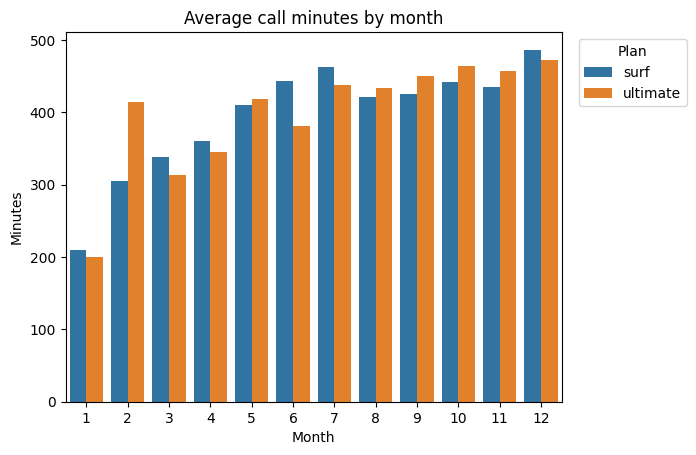

In [118]:
# Gráfico de barras para compara la duración promedio de llamadas por cada plan y por cada mes.

g = sns.barplot(data = user_month_data, y= "calls_time", x= "month", hue = "plan", 
                hue_order = ["surf","ultimate"], alpha = 1, ci = None)
g.set_title("Average call minutes by month")
g.set_xlabel("Month")
g.set_ylabel("Minutes")
g.legend(title="Plan", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

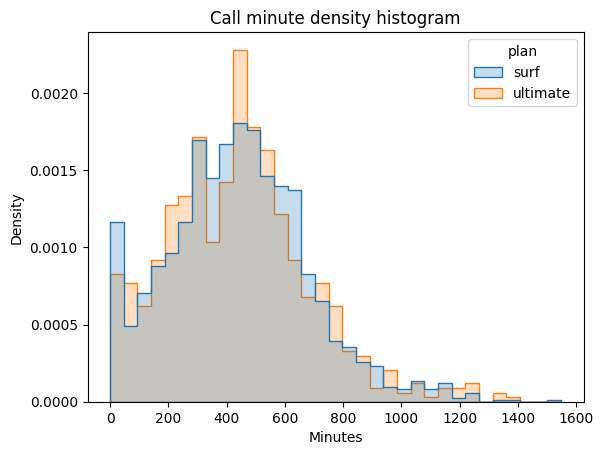

In [119]:
# Histograma para comparar el número de minutos mensuales que necesitan los usuarios de cada plan. Densidad.

g = sns.histplot(x= "calls_time",data = user_month_data, hue = "plan",
                 hue_order= ["surf","ultimate"], element = "step", stat="density", common_norm = False)
g.set_title("Call minute density histogram")
g.set_xlabel("Minutes")
g.set_ylabel("Density")
plt.show()


In [120]:
# Calcular la media y la varianza de la duración mensual de llamadas en ambos planes.

surf_call_minutes = user_month_data[user_month_data["plan"]=="surf"]["calls_time"]
ultimate_call_minutes = user_month_data[user_month_data["plan"]=="ultimate"]["calls_time"]

surf_call_mean = surf_call_minutes.mean()
surf_call_var = surf_call_minutes.var()

ultimate_call_mean = ultimate_call_minutes.mean()
ultimate_call_var = ultimate_call_minutes.var()

print(f"Media: surf = {surf_call_mean:.3f}, ultimate = {ultimate_call_mean:.3f}")
print(f"Varianza: surf = {surf_call_var:,.3f}, ultimate = {ultimate_call_var:,.3f}")

Media: surf = 440.324, ultimate = 442.432
Varianza: surf = 57,743.746, ultimate = 60,876.012


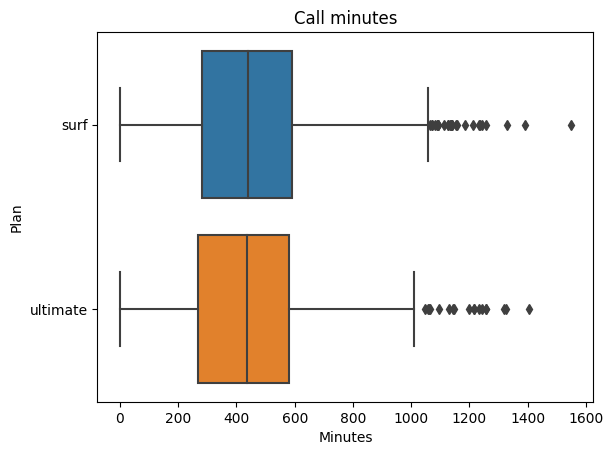

In [121]:
# Diagrama de caja para visualizar la distribución de la duración mensual de llamadas

g = sns.boxplot(y="plan", x ="calls_time",data = user_month_data, order= ["surf","ultimate"])
g.set_title("Call minutes")
g.set_ylabel("Plan")
g.set_xlabel("Minutes")
plt.show()

**Conclusiones**

La distribución de minutos mensuales no parece tener diferencia ente los dos planes pues las medias son muy similares y también la diferencia en las varianzas es pequeña. También la forma de la distribución es similar aunque la del plan surf está algo más sesgado hacia la derecha que la del plan ultimate.

### Mensajes

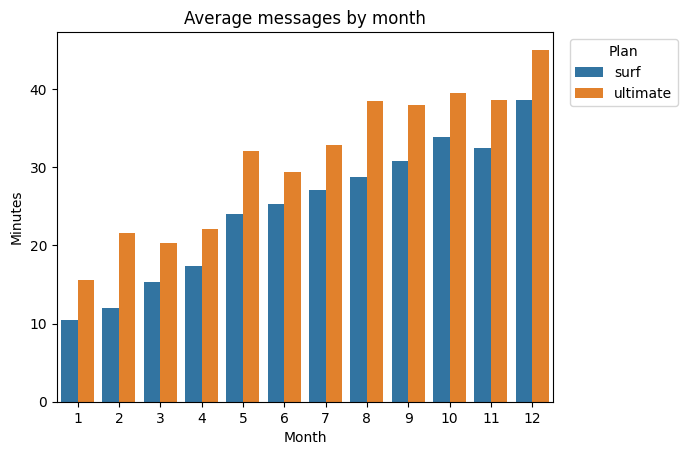

In [122]:
# Gráfico de barras para compara el número promedio de mensajes por cada plan y por cada mes.

g = sns.barplot(data = user_month_data, y= "messages_count", x= "month", hue = "plan", 
                hue_order = ["surf","ultimate"], alpha = 1, ci = None)
g.set_title("Average messages by month")
g.set_xlabel("Month")
g.set_ylabel("Minutes")
g.legend(title="Plan", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

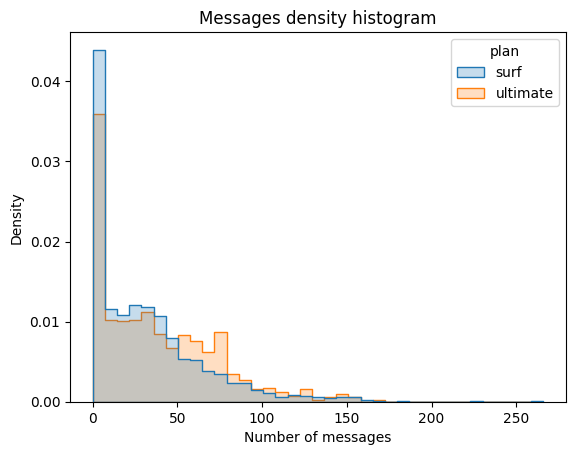

In [123]:
# Comparar el número de mensajes que tienden a enviar cada mes los usuarios de cada plan 
# Histograma de densidad 

g = sns.histplot(x= "messages_count",data = user_month_data, hue = "plan",
                 hue_order= ["surf","ultimate"], element = "step", stat="density", common_norm = False)
g.set_title("Messages density histogram")
g.set_xlabel("Number of messages")
g.set_ylabel("Density")
plt.show()

In [124]:
# Calcular la media y la varianza de la duración mensual de llamadas.

surf_messages_count = user_month_data[user_month_data["plan"]=="surf"]["messages_count"]
ultimate_messages_count = user_month_data[user_month_data["plan"]=="ultimate"]["messages_count"]

surf_messages_mean = surf_messages_count.mean()
surf_messages_var = surf_messages_count.var()

ultimate_messages_mean = ultimate_messages_count.mean()
ultimate_messages_var = ultimate_messages_count.var()

print(f"Media: surf = {surf_messages_mean:.3f}, ultimate = {ultimate_messages_mean:.3f}")
print(f"Varianza: surf = {surf_messages_var:,.3f}, ultimate = {ultimate_messages_var:,.3f}")


Media: surf = 31.160, ultimate = 37.551
Varianza: surf = 1,126.725, ultimate = 1,208.757


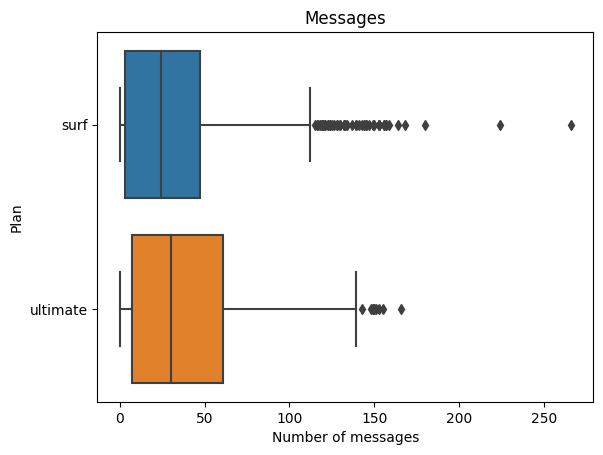

In [125]:
# Diagrama de caja para visualizar la distribución del número de mensajes mensual

g = sns.boxplot(y="plan", x ="messages_count",data = user_month_data, order= ["surf","ultimate"])
g.set_title("Messages")
g.set_ylabel("Plan")
g.set_xlabel("Number of messages")
plt.show()


**Conclusión**

En el caso de los mensajes de texto se aprecian diferencias en las distribuciones de los dos planes. La diferencia en la media es pequeña, a favor del plan ultimate, y la varianza es prácticamente la misma.
Lo más diferenciable es la dispersión, teniendo el plan surf un intervalo intercuartílico menor, aunque hay atípicos más extremos en este plan. 

### Internet

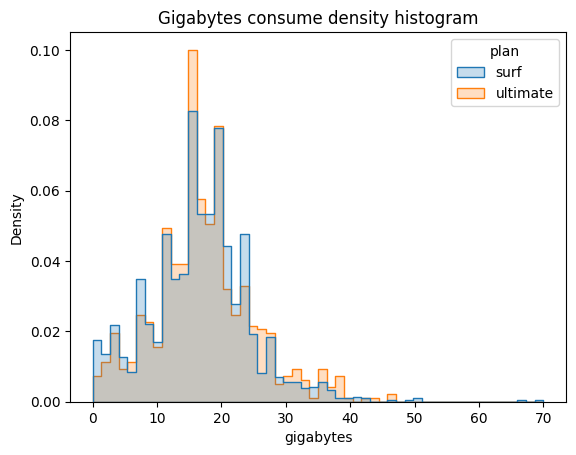

In [126]:
# Comparar la cantidad de tráfico de Internet consumido por usuarios por plan
# Histograma de densidad 

g = sns.histplot(x= "gb_used",data = user_month_data, hue = "plan",
                 hue_order= ["surf","ultimate"], element = "step", stat="density", common_norm = False)
g.set_title("Gigabytes consume density histogram")
g.set_xlabel("gigabytes")
g.set_ylabel("Density")
plt.show()

In [127]:
# Calcular la media y la varianza del número de gigabytes consumidos por usuario al mes

surf_gb_count = user_month_data[user_month_data["plan"]=="surf"]["gb_used"]
ultimate_gb_count = user_month_data[user_month_data["plan"]=="ultimate"]["gb_used"]

surf_gb_mean = surf_gb_count.mean()
surf_gb_var = surf_gb_count.var()

ultimate_gb_mean = ultimate_gb_count.mean()
ultimate_gb_var = ultimate_gb_count.var()

print(f"Media: surf = {surf_gb_mean:.3f}, ultimate = {ultimate_gb_mean:.3f}")
print(f"Varianza: surf = {surf_gb_var:,.3f}, ultimate = {ultimate_gb_var:,.3f}")

Media: surf = 16.667, ultimate = 17.307
Varianza: surf = 61.587, ultimate = 58.831


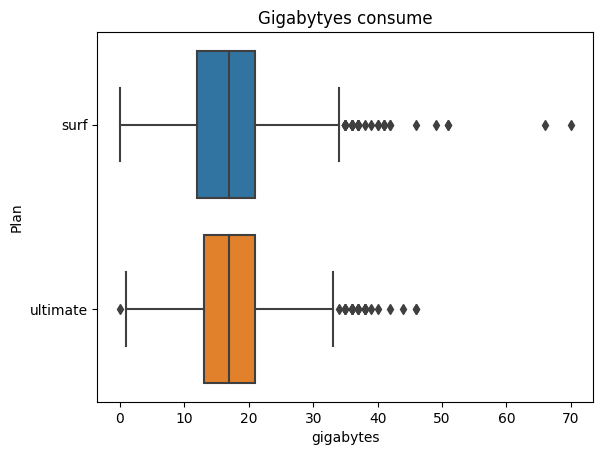

In [128]:
# Diagrama de caja para visualizar la distribución del número de gigabytes consumidos por usuario al mes

g = sns.boxplot(y="plan", x ="gb_used",data = user_month_data, order= ["surf","ultimate"])
g.set_title("Gigabytyes consume")
g.set_ylabel("Plan")
g.set_xlabel("gigabytes")
plt.show()

**Conclusión**

El análisis revela que el consumo de internet, en gigabytes, es muy similar tanto en dispersión como media. De nuevo hay atípicos más extremos en el plan Surf.

### Ingreso

In [129]:
# Total de USD para toda la categoría

user_month_data.groupby("plan")["income"].sum()

plan
surf        95764.21
ultimate    52066.00
Name: income, dtype: float64

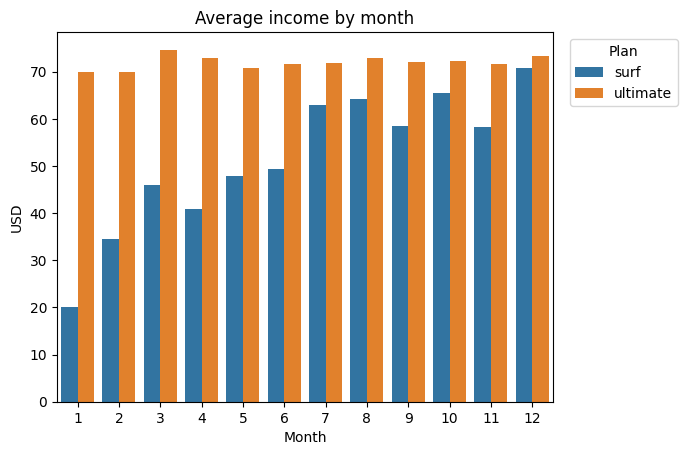

In [130]:
# Gráfico de barras para compara el ingreso promedio de usuarios al mes

g = sns.barplot(data = user_month_data, y= "income", x= "month", hue = "plan", hue_order = ["surf","ultimate"], alpha = 1, ci = None) # version de seaplot 0.11
g.set_title("Average income by month")
g.set_xlabel("Month")
g.set_ylabel("USD")
g.legend(title="Plan", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

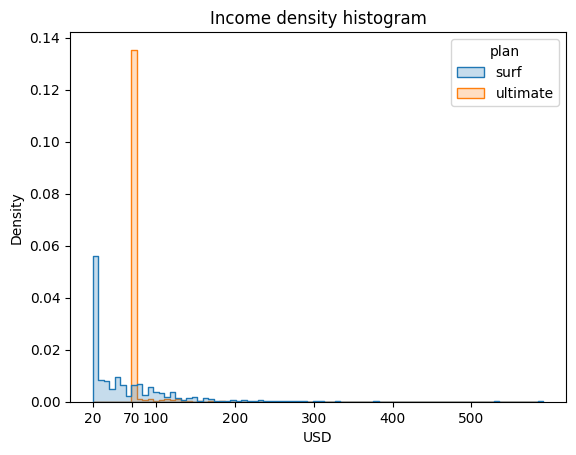

In [131]:
# Comparar la cantidad de ingresos en USD por usuarios por plan
# Histograma de densidad 

g = sns.histplot(x= "income",data = user_month_data, hue = "plan",
                 hue_order= ["surf","ultimate"], element = "step", stat="density", common_norm = False)
g.set_title("Income density histogram")
g.set_xlabel("USD")
g.set_ylabel("Density")
g.set_xticks([20,70,100,200,300,400,500])
plt.show()

In [132]:
# Calcular la media y la varianza del ingreso mensual

surf_income_count = user_month_data[user_month_data["plan"]=="surf"]["income"]
ultimate_income_count = user_month_data[user_month_data["plan"]=="ultimate"]["income"]

surf_income_mean = surf_income_count.mean()
surf_income_var = surf_income_count.var()

ultimate_income_mean = ultimate_income_count.mean()
ultimate_income_var = ultimate_income_count.var()

print(f"Media: surf = {surf_income_mean:.3f}, ultimate = {ultimate_income_mean:.3f}")
print(f"Varianza: surf = {surf_income_var:,.3f}, ultimate = {ultimate_income_var:,.3f}")

Media: surf = 60.880, ultimate = 72.314
Varianza: surf = 3,073.889, ultimate = 129.848


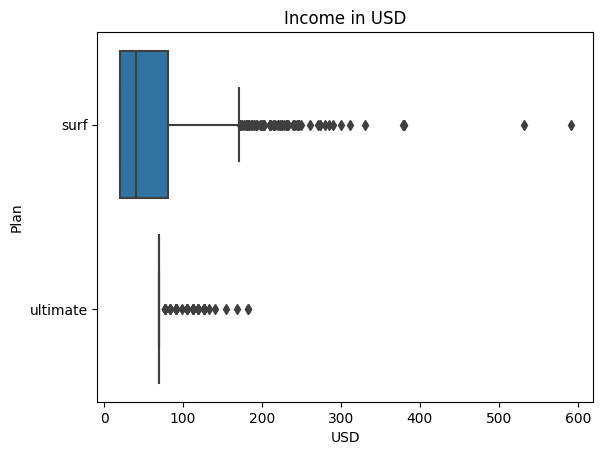

In [133]:
# Diagrama de caja para visualizar la distribución del ingreso mensual promedio 

g = sns.boxplot(y="plan", x ="income",data = user_month_data, order= ["surf","ultimate"])
g.set_title("Income in USD")
g.set_ylabel("Plan")
g.set_xlabel("USD")
plt.show()

**Conclusión**

La comparación del ingreso para los dos planes revela que este se mantiene en \\$70 USD para la gran mayoría de los usuarios del plan ultimate. En cambio para el plan surf hay una mayor dispersión que provoca que a pesar de que la mayoría de los usuarios generan un ingreso de \\$20 USD, la media sube hasta los \\$60 USD.

Para Megaline los ingresos brutos, no promedio, correspondientes al plan *Surf* son más del **80%** (92 000 vs 52 000) superiores al plan *Ultimate*, compensando la tarifa menor con el doble de usuarios. Al menos con esta muestra de 500 usuarios.

### Ciudad

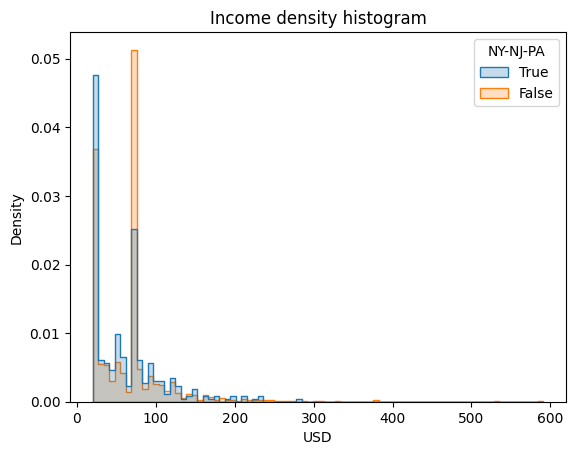

In [134]:
# Comparar la cantidad de ingresos en USD por usuarios por ciudad
# Histograma de densidad 

g = sns.histplot(x= "income",data = user_month_data, hue = "NY-NJ-PA", 
                 hue_order=[True,False], element = "step", stat="density", common_norm = False)
g.set_title("Income density histogram")
g.set_xlabel("USD")
g.set_ylabel("Density")
plt.show()

In [135]:
# Calcular la media y la varianza del ingreso mensual

ny_income_count = user_month_data[user_month_data["NY-NJ-PA"]== True]["income"]
other_income_count = user_month_data[user_month_data["NY-NJ-PA"]==False]["income"]

ny_income_mean = ny_income_count.mean()
ny_income_var = ny_income_count.var()

other_income_mean = other_income_count.mean()
other_income_var = other_income_count.var()

print(f"Media: NY-NJ = {ny_income_mean:.3f}, Otros = {other_income_mean:.3f}")
print(f"Varianza: NY-NJ = {ny_income_var:,.3f}, Otros = {other_income_var:,.3f}")

Media: NY-NJ = 60.081, Otros = 65.334
Varianza: NY-NJ = 1,897.819, Otros = 2,228.624


**Conclusión**

Las distribuciones son distintas: si bien tanto dentro de NY-NJ como fuera hay dos picos notorios, \\$20 y \\$70 USD, el pico de \\$20 USD es más grande en NY-NJ y el pico de \\$70 USD es más grande fuera de esa región. 

## Prueba las hipótesis estadísticas

### Surf vs Ultimate

Con las gráficas tenemos la intuición de que en promedio los usuarios del plan Ultimate aportan más ingresos que los del plan Surf. 

A continuación se probará la hipótesis con métodos estadísticos. 

Hipótesis nula : 
 - El promedio de los ingresos del plan *surf* es igual al promedio de ingresos del plan *ultimate*.

Hipótesis alternativa:
 - Es que el **promedio** de los ingresos de ambos planes es **diferente**.

Para probar esta hipótesis se usará una prueba t de Student de dos colas para dos poblaciones independientes, con un nivel de significación **alpha = 0.05** (5%)


In [136]:
# Prueba las hipótesis

alpha = 0.05
results = st.ttest_ind(user_month_data[user_month_data["plan"]=="surf"]["income"],
                       user_month_data[user_month_data["plan"]=="ultimate"]["income"], equal_var = False)
print(f'valor p: {results.pvalue:.2e}')
#print(results)
if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 8.42e-15
Rechazamos la hipótesis nula


### NY-NJ vs Otros

También es de interés saber si estadísticamente los usuarios del área NY-NJ-PA ingresan lo mismo que el resto de regiones, en promedio, para esto:

Hipótesis nula : 
 - El promedio de los ingresos del área NY-NJ es igual al promedio de ingresos del resto de regiones.

Hipótesis alternativa:
 - Es que el **promedio** de los ingresos de ambas regiones es **diferente**.

Se usará una prueba t de Student de dos colas para dos poblaciones independientes, con un nivel de significación **alpha = 0.05** (5%)

In [137]:
# Prueba las hipótesis

alpha = 0.05
results = st.ttest_ind(user_month_data[user_month_data["NY-NJ-PA"]==True]["income"],
                       user_month_data[user_month_data["NY-NJ-PA"]==False]["income"], equal_var = False)
print(f'valor p: {results.pvalue:.2e}')
#print(results)
if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 3.53e-02
Rechazamos la hipótesis nula


## Conclusión general

1. Preprocesamiento
   - Los datos no requirieron tratamiento de valores ausentes o eliminación de duplicados, y los valores se encontraron dentro de los rangos esperados.
   - Fue necesario agregar información sobre el valor de las tarifas
   - Renombrar columnas llamadas *id* evita errores cuando se combinan tablas.
   - Las fechas se convirtieron al tipo de dato correspondiente.
   - Columnas agregadas:
     1. Mes, para cada campo de fecha
     2. Región, acortando el campo 'city'
2. Surf vs Ultimate
   - Tanto en los minutos en llamadas con en gb de internet no hay una diferencia aparente en la cantidad usada para usuarios de ambos planes. Mientras que para los mensajes enviados la diferencia es pequeña.
   - Hay casi el doble de usuarios del plan Surf que del plan Ultimate
   - Sumando todos los ingresos el plan Surf aporta alrededor de un 60% más que el plan Ultimate
   - El promedio de ingresos de cada plan es **60.88** para el plan *Surf* y **72.31** para el plan *ultimate*
   - La prueba t de Student rechaza la hipótesis de que en promedio los usuarios de ambos planes tienen el mismo ingreso.
4. NY-NJ vs Otros
   - El 16% (80 de 500) de los usuarios viven en NY-NJ.
      El promedio de ingresos de cada área es **60.08** para el área *NY-NJ* y **65.33** para el *resto de áreas*.